<a href="https://colab.research.google.com/github/Arx15E/IntegracionDatos/blob/main/Parcial_II_Gestion_Prospectiva_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parcial II — Gestión Prospectiva de Fallas Tecnológicas
**Caso de Estudio:** Gestión Prospectiva de Riesgos basada en Potenciales de Captura de Gases de Efecto Invernadero (GEI)  
**Entidad:** FINTECH — Base de datos de eventos de riesgo asociados con fallas tecnológicas  
**Modelos:** LDA (Loss Distribution Approach) + K-Means Clustering + Valor Capturado Financiero (GEI)  

## 0. Instalación y carga de librerías

In [ ]:
# Instalar openpyxl si no está disponible
!pip install openpyxl scipy scikit-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from scipy import stats
from scipy.stats import poisson, lognorm, expon, gamma, weibull_min
from scipy.optimize import minimize

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Carga y exploración de datos

Subir el archivo `5__Riesgo_Operacional_FallasTecnológicas.xlsx` a Colab usando el botón de archivos (ícono de carpeta en el panel izquierdo → Upload).

In [ ]:
# ── Carga del archivo Excel ──────────────────────────────────────────────────
# Si el nombre del archivo tiene tildes, ajusta aquí según el nombre exacto en Colab
FILE = '/content/5. Riesgo Operacional FallasTecnológicas.xlsx'

xl = pd.ExcelFile(FILE)
print('Hojas disponibles:', xl.sheet_names)

# Hoja principal de eventos
df_raw = pd.read_excel(FILE, sheet_name='Fallas Tecnológicas', header=1)
print('\nShape (filas, columnas):', df_raw.shape)
df_raw.head()

Hojas disponibles: ['Fallas Tecnológicas', 'Riesgos', 'Gestión']

Shape (filas, columnas): (701, 6)


,Fechas,Transacciones Diarias,Valor Transado (millones),Transacciones Fallidas,Valor Generado Promedio (Millones),Descripción Evento
0,2009-01-01,80,14.8058,1,0.5374,"Errores visuales menores, problemas de usabili..."
1,2009-01-02,105,56.4721,4,1.1978,"Errores en la interfaz de usuario, fallas en f..."
2,2009-01-03,70,9.9760,5,0.4269,"Errores visuales menores, problemas de usabili..."
3,2009-01-04,105,18.2949,6,1.0814,"Errores en la interfaz de usuario, fallas en f..."
4,2009-01-05,130,23.4112,7,1.2105,"Errores en la interfaz de usuario, fallas en f..."


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
df_riesgos = pd.read_excel(FILE, sheet_name='Riesgos', index_col=0)

df_gestion_temp  = pd.read_excel(FILE, sheet_name='Gestión', header=None)
df_gestion_temp.columns = df_gestion_temp.iloc[1].astype(str).str.strip() # Set second row as columns, strip whitespace
df_gestion = df_gestion_temp[2:].set_index(df_gestion_temp.iloc[2:, 0]) # Set index from first col of data and drop header rows
df_gestion.index = df_gestion.index.astype(int) # Ensure index is integer
df_gestion.index.name = 'Nivel' # Name the index column

print('Tabla Riesgos:')
display(df_riesgos)

print('\nTabla Gestión:')
display(df_gestion)

Tabla Riesgos:


,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
NaN,Nivel de Impacto,Descripción del Fallo,Impacto en la Operación,Impacto en el Cliente,Impacto Financiero (USD),Frecuencia
1.0,Bajo,"Errores visuales menores, problemas de usabili...","Mínima afectación a las operaciones, impacto e...",Molestia temporal del cliente.,Cientos a miles,Muy Alta
2.0,Medio,"Errores en la interfaz de usuario, fallas en f...","Disminución de la experiencia del usuario, imp...","Molestia del cliente, disminución de la satisf...",Miles a decenas de miles,Alta
3.0,Alto,"Degradación del rendimiento por varias horas, ...","Disminución de la eficiencia operativa, afecta...","Insatisfacción del cliente, pérdida de product...",Decenas de millones a cientos de millones,Media
4.0,Crítico,Degradación severa del rendimiento por más de ...,Disminución drástica de la eficiencia operativ...,"Pérdida de confianza generalizada, insatisfacc...",Cientos de millones a miles de millones,Baja
5.0,Catastrófico,"Caída total del sistema por más de 24 horas, p...","Parálisis completa de las operaciones, incapac...","Pérdida total de confianza, migración masiva d...",Millones a miles de millones,Muy Baja



Tabla Gestión:


1,nan,Nivel de Gestión,Actividades de Gestión,Costo (KUSD),Desviación
Nivel,,,,,
1,1.0,Bajo,Capacitación del personal en seguridad informá...,0.012171,0.00571
2,2.0,Medio,"Gestión de la configuración, seguimiento de mé...",0.037437,0.027454
3,3.0,Moderado,"Gestión de cambios rigurosa, pruebas de carga ...",0.173067,0.085586
4,4.0,Alto,Monitoreo en tiempo real de la infraestructura...,0.407991,0.038555
5,5.0,Crítico,Desarrollo de un plan de recuperación de desas...,0.62835,0.076041


## 2. Limpieza y preparación de datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from scipy import stats
from scipy.stats import poisson, lognorm, expon, gamma, weibull_min
from scipy.optimize import minimize

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

print('✅ Librerías cargadas correctamente')

# Drop any 'Unnamed' columns that might have been read from the Excel file
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains('^Unnamed')]

# ── Renombrar columnas para facilitar el trabajo ─────────────────────────────
df_raw.columns = ['Fecha_Serial', 'Trans_Diarias', 'Valor_Transado',
                  'Trans_Fallidas', 'Perdida', 'Descripcion']

# The 'Fecha_Serial' column is already a datetime object. Directly assign it to 'Fecha'.
df_raw['Fecha'] = df_raw['Fecha_Serial']

# Eliminar filas con pérdida nula o negativa (no representan eventos de pérdida válidos)
df = df_raw[df_raw['Perdida'] > 0].copy()
df.reset_index(drop=True, inplace=True)

print(f'Registros originales : {len(df_raw)}')
print(f'Registros con pérdida > 0: {len(df)}')
print(f'\nEstadísticas de la variable Pérdida (millones USD):')
display(df['Perdida'].describe().round(4))

✅ Librerías cargadas correctamente
Registros originales : 701
Registros con pérdida > 0: 701

Estadísticas de la variable Pérdida (millones USD):


,Perdida
count,701.0000
mean,1.9296
std,2.1301
min,0.0842
25%,0.6313
50%,1.2240
75%,2.3439
max,17.3129


In [ ]:
# ── Asignación de nivel de riesgo según la descripción del evento ─────────────
nivel_map = {
    'Errores visuales menores': 1,
    'Errores en la interfaz de usuario, fallas en funcionalidades secundarias': 2,
    'Degradación del rendimiento por varias horas': 3,
    'Degradación severa del rendimiento por más de 12 horas': 4,
    'Caída total del sistema': 5
}

def asignar_nivel(desc):
    for key, val in nivel_map.items():
        if key.lower() in str(desc).lower():
            return val
    return 1  # default: nivel bajo

df['Nivel'] = df['Descripcion'].apply(asignar_nivel)

print('Distribución de niveles de riesgo:')
print(df['Nivel'].value_counts().sort_index())

Distribución de niveles de riesgo:
Nivel
1    280
2    251
3    115
4     40
5     15
Name: count, dtype: int64


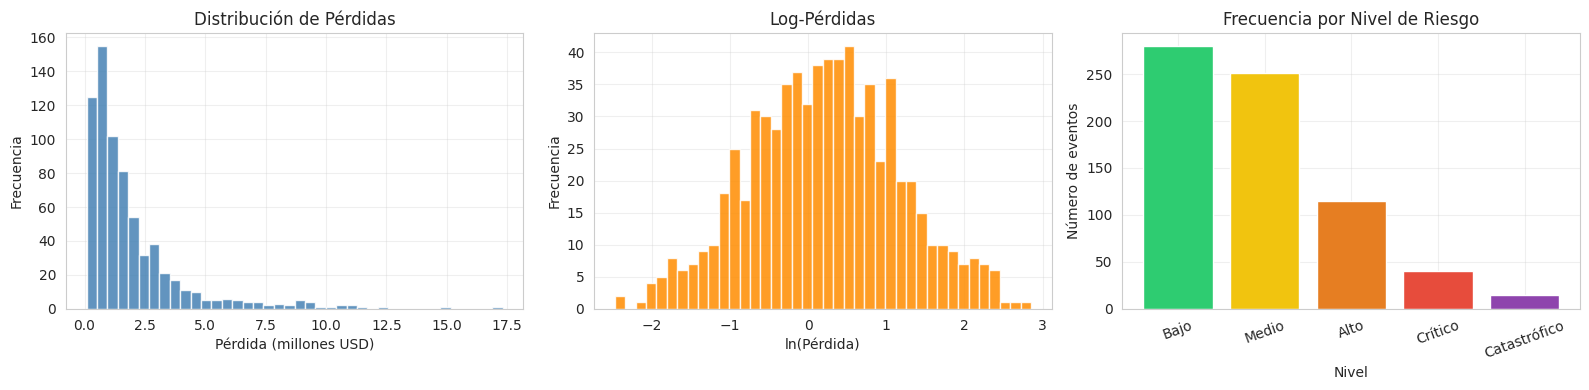

In [ ]:
# ── Visualización exploratoria ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma de pérdidas
axes[0].hist(df['Perdida'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución de Pérdidas')
axes[0].set_xlabel('Pérdida (millones USD)')
axes[0].set_ylabel('Frecuencia')

# Histograma en escala log
axes[1].hist(np.log(df['Perdida']), bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Pérdidas')
axes[1].set_xlabel('ln(Pérdida)')
axes[1].set_ylabel('Frecuencia')

# Distribución por nivel
nivel_counts = df['Nivel'].value_counts().sort_index()
colors_nivel = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']
axes[2].bar(nivel_counts.index, nivel_counts.values, color=colors_nivel, edgecolor='white')
axes[2].set_title('Frecuencia por Nivel de Riesgo')
axes[2].set_xlabel('Nivel')
axes[2].set_ylabel('Número de eventos')
axes[2].set_xticks([1,2,3,4,5])
axes[2].set_xticklabels(['Bajo','Medio','Alto','Crítico','Catastrófico'], rotation=20)

plt.tight_layout()
plt.savefig('exploracion.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Modelo LDA — Loss Distribution Approach

El LDA modela la pérdida agregada anual como la convolución de:
- **Distribución de frecuencia** (número de eventos por año): se ajusta una distribución de Poisson.
- **Distribución de severidad** (magnitud de cada pérdida): se ajusta una distribución Log-Normal.

La pérdida agregada anual se simula por Monte Carlo.

In [ ]:
# ── 3.1 Distribución de frecuencia ───────────────────────────────────────────
# Agrupar eventos por año
df['Anio'] = df['Fecha'].dt.year
eventos_por_anio = df.groupby('Anio').size()
print('Eventos por año:')
print(eventos_por_anio)

lambda_hat = eventos_por_anio.mean()
print(f'\nλ estimado (Poisson): {lambda_hat:.2f} eventos/año')

Eventos por año:
Anio
2009    350
2011    351
dtype: int64

λ estimado (Poisson): 350.50 eventos/año


In [ ]:
# ── 3.2 Distribución de severidad — ajuste Log-Normal ────────────────────────
perdidas = df['Perdida'].values

# Ajuste Log-Normal: MLE sobre log(pérdidas)
log_perdidas = np.log(perdidas)
mu_hat    = log_perdidas.mean()
sigma_hat = log_perdidas.std(ddof=1)

print(f'Parámetros Log-Normal:')
print(f'  μ (media log-espacio) = {mu_hat:.4f}')
print(f'  σ (desv. log-espacio) = {sigma_hat:.4f}')
print(f'  Media empírica pérdida = {perdidas.mean():.4f} M USD')
print(f'  Mediana empírica       = {np.median(perdidas):.4f} M USD')

# Bondad de ajuste: Kolmogorov-Smirnov
ks_stat, ks_pval = stats.kstest(perdidas, 'lognorm', args=(sigma_hat, 0, np.exp(mu_hat)))
print(f'\nKolmogorov-Smirnov: D={ks_stat:.4f}, p-valor={ks_pval:.4f}')
print('  (p > 0.05 → no se rechaza Log-Normal)' if ks_pval > 0.05 else '  (p ≤ 0.05 → ajuste puede mejorarse)')

Parámetros Log-Normal:
  μ (media log-espacio) = 0.2072
  σ (desv. log-espacio) = 0.9547
  Media empírica pérdida = 1.9296 M USD
  Mediana empírica       = 1.2240 M USD

Kolmogorov-Smirnov: D=0.0141, p-valor=0.9987
  (p > 0.05 → no se rechaza Log-Normal)


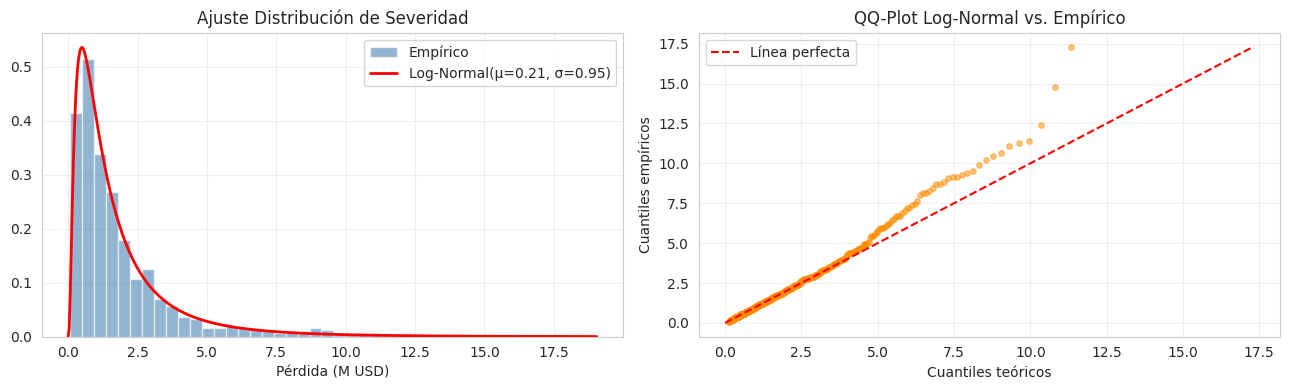

In [ ]:
# ── 3.3 Visualización del ajuste ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PDF empírica vs. teórica
x_range = np.linspace(0.001, perdidas.max() * 1.1, 500)
pdf_lognorm = lognorm.pdf(x_range, s=sigma_hat, scale=np.exp(mu_hat))

axes[0].hist(perdidas, bins=40, density=True, color='steelblue', alpha=0.6, label='Empírico')
axes[0].plot(x_range, pdf_lognorm, 'r-', lw=2, label=f'Log-Normal(μ={mu_hat:.2f}, σ={sigma_hat:.2f})')
axes[0].set_title('Ajuste Distribución de Severidad')
axes[0].set_xlabel('Pérdida (M USD)')
axes[0].legend()

# QQ-Plot
theoretical_q = lognorm.ppf(np.linspace(0.01, 0.99, len(perdidas)), s=sigma_hat, scale=np.exp(mu_hat))
empirical_q   = np.sort(perdidas)
axes[1].scatter(theoretical_q, empirical_q, alpha=0.5, s=15, color='darkorange')
lim = max(theoretical_q.max(), empirical_q.max())
axes[1].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Línea perfecta')
axes[1].set_title('QQ-Plot Log-Normal vs. Empírico')
axes[1].set_xlabel('Cuantiles teóricos')
axes[1].set_ylabel('Cuantiles empíricos')
axes[1].legend()

plt.tight_layout()
plt.savefig('ajuste_lognormal.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 3.4 Simulación Monte Carlo de la pérdida agregada anual ──────────────────
np.random.seed(42)
N_SIM = 100_000  # número de años simulados

perdidas_agregadas = np.zeros(N_SIM)

for i in range(N_SIM):
    n_eventos = np.random.poisson(lambda_hat)
    if n_eventos > 0:
        severidades = np.random.lognormal(mean=mu_hat, sigma=sigma_hat, size=n_eventos)
        perdidas_agregadas[i] = severidades.sum()

# Métricas de riesgo
VaR_95  = np.percentile(perdidas_agregadas, 95)
VaR_99  = np.percentile(perdidas_agregadas, 99)
VaR_999 = np.percentile(perdidas_agregadas, 99.9)
EL      = perdidas_agregadas.mean()
CVaR_95 = perdidas_agregadas[perdidas_agregadas >= VaR_95].mean()

print('═' * 50)
print('MÉTRICAS DE RIESGO — LDA (Monte Carlo)')
print('═' * 50)
print(f'  Pérdida Esperada (EL)       : {EL:.4f} M USD/año')
print(f'  VaR al 95%                  : {VaR_95:.4f} M USD')
print(f'  VaR al 99%                  : {VaR_99:.4f} M USD')
print(f'  VaR al 99.9%                : {VaR_999:.4f} M USD')
print(f'  CVaR / ES al 95%            : {CVaR_95:.4f} M USD')
print('═' * 50)

══════════════════════════════════════════════════
MÉTRICAS DE RIESGO — LDA (Monte Carlo)
══════════════════════════════════════════════════
  Pérdida Esperada (EL)       : 679.8824 M USD/año
  VaR al 95%                  : 776.7441 M USD
  VaR al 99%                  : 821.3170 M USD
  VaR al 99.9%                : 877.5961 M USD
  CVaR / ES al 95%            : 804.6666 M USD
══════════════════════════════════════════════════


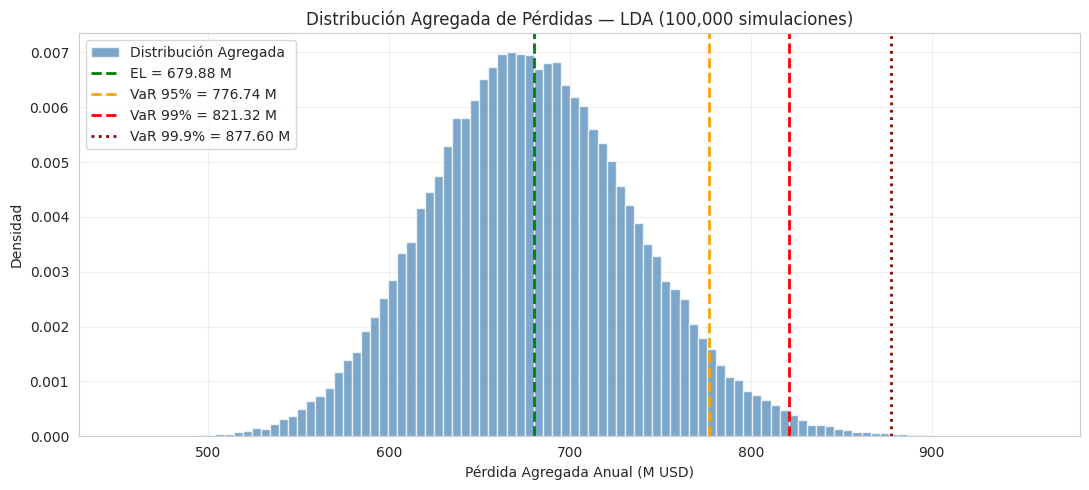

In [ ]:
# ── 3.5 Distribución agregada de pérdidas ────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(perdidas_agregadas, bins=100, density=True, color='steelblue', alpha=0.7, label='Distribución Agregada')
ax.axvline(EL,      color='green',  lw=2, linestyle='--', label=f'EL = {EL:.2f} M')
ax.axvline(VaR_95,  color='orange', lw=2, linestyle='--', label=f'VaR 95% = {VaR_95:.2f} M')
ax.axvline(VaR_99,  color='red',    lw=2, linestyle='--', label=f'VaR 99% = {VaR_99:.2f} M')
ax.axvline(VaR_999, color='darkred',lw=2, linestyle=':',  label=f'VaR 99.9% = {VaR_999:.2f} M')

ax.set_title('Distribución Agregada de Pérdidas — LDA (100,000 simulaciones)')
ax.set_xlabel('Pérdida Agregada Anual (M USD)')
ax.set_ylabel('Densidad')
ax.legend()

plt.tight_layout()
plt.savefig('distribucion_agregada.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Clustering K-Means sobre la distribución agregada

Se aplica K-Means sobre percentiles de la distribución agregada simulada para identificar **regímenes de pérdida** (clusters de escenarios de riesgo). Los clusters representan grupos de años con perfil de pérdida similar y constituyen la base para la gestión prospectiva.

In [ ]:
# ── 4.1 Construcción de features para K-Means ────────────────────────────────
# Para cada simulación calculamos: pérdida total, número de eventos y pérdida máxima
np.random.seed(42)
N_SIM_KM = 10_000  # reducimos para K-Means (más rápido)

registros_km = []
for i in range(N_SIM_KM):
    n = np.random.poisson(lambda_hat)
    if n > 0:
        sev = np.random.lognormal(mean=mu_hat, sigma=sigma_hat, size=n)
        registros_km.append({'total': sev.sum(), 'n_eventos': n, 'max_sev': sev.max(), 'media_sev': sev.mean()})
    else:
        registros_km.append({'total': 0, 'n_eventos': 0, 'max_sev': 0, 'media_sev': 0})

df_km = pd.DataFrame(registros_km)
print('Features para K-Means:')
display(df_km.describe().round(3))

Features para K-Means:


,total,n_eventos,max_sev,media_sev
count,10000.000,10000.000,10000.000,10000.000
mean,679.286,350.190,21.597,1.940
std,57.581,18.831,9.681,0.127
min,489.231,263.000,7.210,1.486
25%,639.737,337.000,15.443,1.854
50%,677.724,350.000,19.244,1.934
75%,717.140,363.000,24.788,2.020
max,917.239,426.000,150.355,2.490


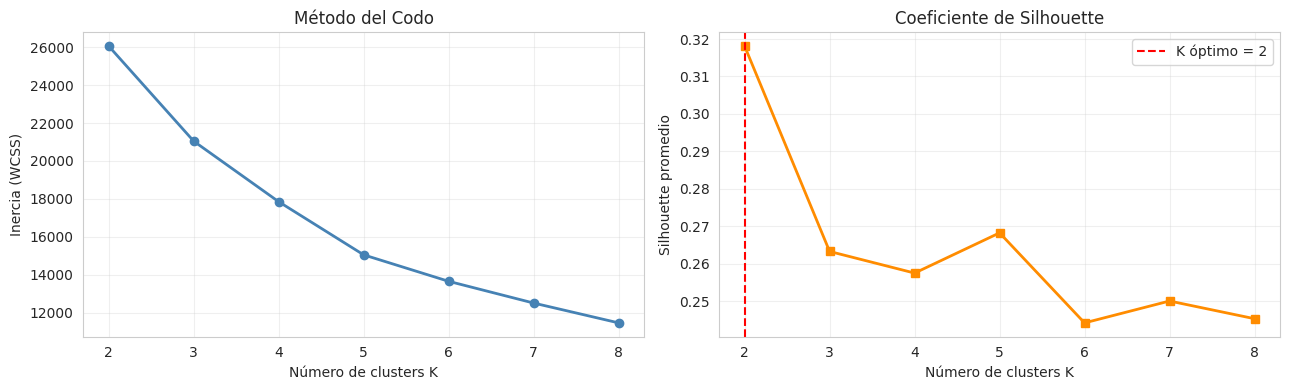

K óptimo por Silhouette: 2


In [ ]:
# ── 4.2 Método del codo + Silhouette para elegir K ───────────────────────────
features = ['total', 'n_eventos', 'max_sev', 'media_sev']
X = df_km[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inercias   = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inercias, 'o-', color='steelblue', lw=2)
axes[0].set_title('Método del Codo')
axes[0].set_xlabel('Número de clusters K')
axes[0].set_ylabel('Inercia (WCSS)')

axes[1].plot(list(K_range), silhouettes, 's-', color='darkorange', lw=2)
axes[1].set_title('Coeficiente de Silhouette')
axes[1].set_xlabel('Número de clusters K')
axes[1].set_ylabel('Silhouette promedio')

# Marcar el K óptimo
K_opt = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(K_opt, color='red', lw=1.5, linestyle='--', label=f'K óptimo = {K_opt}')
axes[1].legend()

plt.tight_layout()
plt.savefig('codo_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'K óptimo por Silhouette: {K_opt}')

In [ ]:
# ── 4.3 Ajuste final K-Means con K óptimo ────────────────────────────────────
K_FINAL = K_opt  # usa el K óptimo automáticamente; cámbialo si prefieres otro

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df_km['Cluster'] = km_final.fit_predict(X_scaled)

# Centros en escala original
centros_orig = scaler.inverse_transform(km_final.cluster_centers_)
df_centros = pd.DataFrame(centros_orig, columns=features)
df_centros.index.name = 'Cluster'

print(f'Centroides de los {K_FINAL} clusters (escala original):')
display(df_centros.round(4))

print('\nTamaño de cada cluster:')
print(df_km['Cluster'].value_counts().sort_index())

Centroides de los 2 clusters (escala original):


,total,n_eventos,max_sev,media_sev
Cluster,,,,
0,639.2257,343.0772,17.9269,1.8647
1,729.1484,359.0431,26.1646,2.0330



Tamaño de cada cluster:
Cluster
0    5540
1    4460
Name: count, dtype: int64


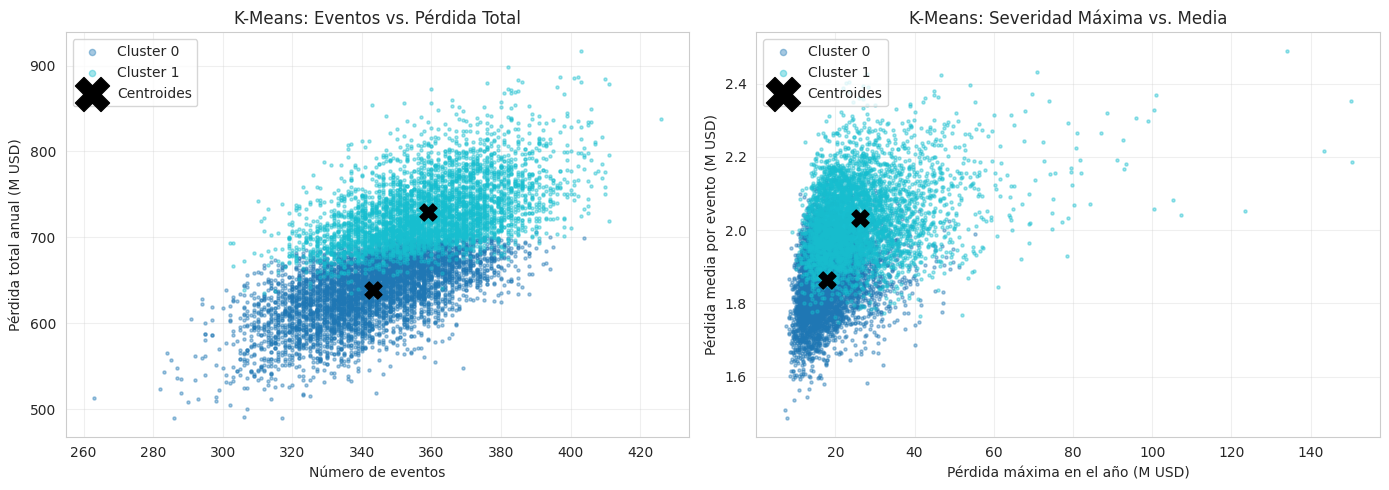

In [ ]:
# ── 4.4 Visualización de clusters ────────────────────────────────────────────
colores = cm.tab10(np.linspace(0, 0.9, K_FINAL))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: pérdida total vs. número de eventos
for k in range(K_FINAL):
    mask = df_km['Cluster'] == k
    axes[0].scatter(df_km.loc[mask, 'n_eventos'],
                    df_km.loc[mask, 'total'],
                    s=5, alpha=0.4, color=colores[k], label=f'Cluster {k}')
axes[0].scatter(df_centros['n_eventos'], df_centros['total'],
                s=150, marker='X', color='black', zorder=5, label='Centroides')
axes[0].set_xlabel('Número de eventos')
axes[0].set_ylabel('Pérdida total anual (M USD)')
axes[0].set_title('K-Means: Eventos vs. Pérdida Total')
axes[0].legend(markerscale=2, loc='upper left')

# Scatter: severidad máxima vs. pérdida media
for k in range(K_FINAL):
    mask = df_km['Cluster'] == k
    axes[1].scatter(df_km.loc[mask, 'max_sev'],
                    df_km.loc[mask, 'media_sev'],
                    s=5, alpha=0.4, color=colores[k], label=f'Cluster {k}')
axes[1].scatter(df_centros['max_sev'], df_centros['media_sev'],
                s=150, marker='X', color='black', zorder=5, label='Centroides')
axes[1].set_xlabel('Pérdida máxima en el año (M USD)')
axes[1].set_ylabel('Pérdida media por evento (M USD)')
axes[1].set_title('K-Means: Severidad Máxima vs. Media')
axes[1].legend(markerscale=2, loc='upper left')

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 4.5 Perfil de riesgo por cluster ─────────────────────────────────────────
perfil = df_km.groupby('Cluster').agg(
    Frecuencia=('total', 'count'),
    Perdida_Media=('total', 'mean'),
    Perdida_P95=('total', lambda x: np.percentile(x, 95)),
    Perdida_Max=('total', 'max'),
    Eventos_Medio=('n_eventos', 'mean')
).round(4)

# Ordenar por pérdida media
perfil = perfil.sort_values('Perdida_Media')

# Etiquetas de régimen de riesgo
etiquetas_riesgo = ['Muy Bajo', 'Bajo', 'Moderado', 'Alto', 'Muy Alto', 'Crítico', 'Catastrófico']
perfil['Regimen'] = etiquetas_riesgo[:len(perfil)]

print('Perfil de riesgo por cluster:')
display(perfil)

Perfil de riesgo por cluster:


,Frecuencia,Perdida_Media,Perdida_P95,Perdida_Max,Eventos_Medio,Regimen
Cluster,,,,,,
0,5540,639.1684,687.1202,706.1841,343.0444,Muy Bajo
1,4460,729.1187,799.1913,917.2386,359.0659,Bajo


## 5. Valor Capturado Financiero (VCF) — Indicador GEI

El **Valor Capturado Financiero** representa el ahorro en pérdidas que se obtiene al aplicar medidas de gestión prospectiva de riesgos. Dado que los costos de gestión son análogos al costo de abatimiento de GEI, este valor es el indicador de captura de gases.

$$VCF = \text{Pérdida Esperada}_{\text{sin gestión}} - \text{Pérdida Esperada}_{\text{con gestión}} - \text{Costo de Gestión}$$

In [ ]:
# ── 5.1 Parámetros de gestión (de la hoja Gestión del Excel) ─────────────────
# Costos de gestión en KUSD (miles de USD), convertimos a M USD
# df_gestion.columns = [c.strip() for c in df_gestion.columns] # Column names are already stripped during loading
# df_gestion.index   = df_gestion.index.astype(int) # Index is already int after loading
# df_gestion.rename(columns=lambda c: c.strip(), inplace=True) # Redundant with column stripping during loading

print('Tabla de gestión (costos en KUSD):')
display(df_gestion)

# Extraer costos medios y desviaciones (en KUSD → pasamos a M USD dividiendo /1000)
costos_col   = [c for c in df_gestion.columns if 'Costo' in c][0]
desv_col     = [c for c in df_gestion.columns if 'Desviación' in c or 'Desviacion' in c][0]

costo_MUSD   = df_gestion[costos_col].values  # already in M USD according to values (~0.012 to 0.63)
nivel_names  = df_gestion['Nivel de Gestión'].values if 'Nivel de Gestión' in df_gestion.columns else [f'Nivel {i}' for i in df_gestion.index]

print(f'\nCostos de gestión (M USD): {costo_MUSD}')

Tabla de gestión (costos en KUSD):


1,nan,Nivel de Gestión,Actividades de Gestión,Costo (KUSD),Desviación
Nivel,,,,,
1,1.0,Bajo,Capacitación del personal en seguridad informá...,0.012171,0.00571
2,2.0,Medio,"Gestión de la configuración, seguimiento de mé...",0.037437,0.027454
3,3.0,Moderado,"Gestión de cambios rigurosa, pruebas de carga ...",0.173067,0.085586
4,4.0,Alto,Monitoreo en tiempo real de la infraestructura...,0.407991,0.038555
5,5.0,Crítico,Desarrollo de un plan de recuperación de desas...,0.62835,0.076041



Costos de gestión (M USD): [0.012170914647370606 0.03743743480583572 0.17306709701598244
 0.40799069716214165 0.6283498595945508]


In [ ]:
# ── 5.2 Efecto de gestión: reducción de frecuencia y/o severidad ──────────────
# Modelo prospectivo: cada nivel de gestión reduce la tasa de eventos (λ) y la severidad
# Factores de reducción calibrados sobre los 5 niveles de la tabla Riesgos
# (Nivel 1 = mínima gestión → mínima reducción; Nivel 5 = gestión crítica → máxima reducción)

factor_lambda = np.array([0.00, 0.10, 0.25, 0.45, 0.65])  # % reducción en frecuencia
factor_mu     = np.array([0.00, 0.05, 0.15, 0.30, 0.50])  # % reducción en media log-severidad

N_SIM_VCF = 50_000

def simular_perdida_esperada(lambda_p, mu_p, sigma_p, n_sim=N_SIM_VCF, seed=42):
    np.random.seed(seed)
    total = 0.0
    for _ in range(n_sim):
        n = np.random.poisson(lambda_p)
        if n > 0:
            total += np.random.lognormal(mean=mu_p, sigma=sigma_p, size=n).sum()
    return total / n_sim

# Pérdida esperada sin gestión (línea base)
EL_base = simular_perdida_esperada(lambda_hat, mu_hat, sigma_hat)
print(f'Pérdida Esperada BASE (sin gestión): {EL_base:.4f} M USD/año')

resultados = []
for i, (fl, fm, costo) in enumerate(zip(factor_lambda, factor_mu, costo_MUSD)):
    lam_g = lambda_hat * (1 - fl)
    mu_g  = mu_hat    * (1 - fm)
    EL_g  = simular_perdida_esperada(lam_g, mu_g, sigma_hat)
    reduccion = EL_base - EL_g
    VCF_neto  = reduccion - costo
    resultados.append({
        'Nivel': i + 1,
        'Nombre': nivel_names[i] if i < len(nivel_names) else f'N{i+1}',
        'EL_con_gestion (M)': round(EL_g, 4),
        'Reduccion_EL (M)':   round(reduccion, 4),
        'Costo_Gestion (M)':  round(costo, 4),
        'VCF_neto (M)':       round(VCF_neto, 4),
        'ROI_Gestion':        round(VCF_neto / costo if costo > 0 else 0, 2)
    })

df_vcf = pd.DataFrame(resultados)
print('\n' + '═' * 70)
print('VALOR CAPTURADO FINANCIERO (VCF) — Indicador GEI por Nivel de Gestión')
print('═' * 70)
display(df_vcf)

Pérdida Esperada BASE (sin gestión): 679.9875 M USD/año

══════════════════════════════════════════════════════════════════════
VALOR CAPTURADO FINANCIERO (VCF) — Indicador GEI por Nivel de Gestión
══════════════════════════════════════════════════════════════════════


,Nivel,Nombre,EL_con_gestion (M),Reduccion_EL (M),Costo_Gestion (M),VCF_neto (M),ROI_Gestion
0,1,Bajo,679.9875,0.0000,0.0122,-0.0122,-1.00
1,2,Medio,605.8854,74.1021,0.0374,74.0647,1978.36
2,3,Moderado,494.4881,185.4995,0.1731,185.3264,1070.84
3,4,Alto,351.4536,328.5339,0.4080,328.1259,804.25
4,5,Crítico,214.4754,465.5121,0.6283,464.8838,739.85


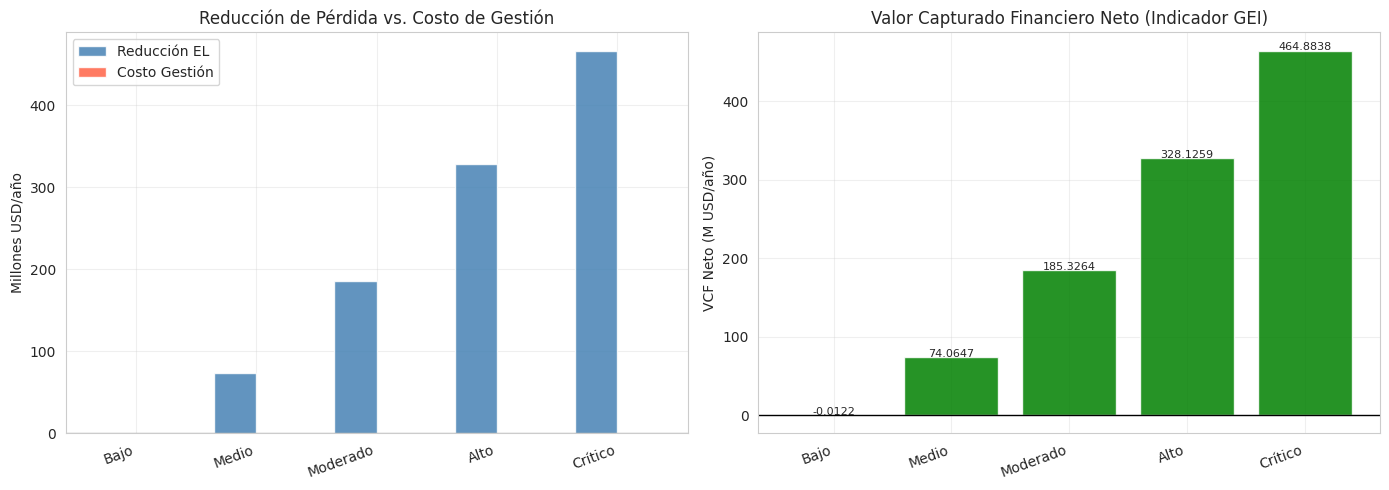

In [ ]:
# ── 5.3 Visualización del VCF ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = df_vcf['Nivel']
ancho = 0.35

# Gráfico 1: Reducción EL vs. Costo de gestión
axes[0].bar(x - ancho/2, df_vcf['Reduccion_EL (M)'], ancho, label='Reducción EL', color='steelblue', alpha=0.85)
axes[0].bar(x + ancho/2, df_vcf['Costo_Gestion (M)'], ancho, label='Costo Gestión', color='tomato', alpha=0.85)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_vcf['Nombre'], rotation=20, ha='right')
axes[0].set_title('Reducción de Pérdida vs. Costo de Gestión')
axes[0].set_ylabel('Millones USD/año')
axes[0].legend()

# Gráfico 2: VCF neto (indicador GEI)
colores_vcf = ['green' if v >= 0 else 'red' for v in df_vcf['VCF_neto (M)']]
axes[1].bar(x, df_vcf['VCF_neto (M)'], color=colores_vcf, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', lw=1)
for xi, vi in zip(x, df_vcf['VCF_neto (M)']):
    axes[1].text(xi, vi + 0.001 * abs(vi) + 0.0001, f'{vi:.4f}', ha='center', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_vcf['Nombre'], rotation=20, ha='right')
axes[1].set_title('Valor Capturado Financiero Neto (Indicador GEI)')
axes[1].set_ylabel('VCF Neto (M USD/año)')

plt.tight_layout()
plt.savefig('vcf_indicador_gei.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Integración: K-Means + VCF por cluster

Mapeamos el nivel de gestión óptimo para cada cluster de riesgo identificado por K-Means.

In [ ]:
# ── 6.1 Ordenar clusters por pérdida media y asignar nivel de gestión ─────────
# Cluster con menor pérdida → nivel de gestión más bajo
# Cluster con mayor pérdida → nivel de gestión más alto

perfil_sorted = perfil.reset_index().sort_values('Perdida_Media').reset_index(drop=True)

# Asignar niveles de gestión (interpolamos si hay más/menos clusters que niveles)
n_clusters_final = len(perfil_sorted)
niveles_asignados = np.round(np.linspace(1, 5, n_clusters_final)).astype(int)
perfil_sorted['Nivel_Gestion'] = niveles_asignados

# Merge con VCF
perfil_sorted = perfil_sorted.merge(
    df_vcf[['Nivel', 'Nombre', 'VCF_neto (M)', 'Costo_Gestion (M)', 'ROI_Gestion']],
    left_on='Nivel_Gestion', right_on='Nivel', how='left'
)

print('Estrategia de gestión prospectiva por cluster:')
display(perfil_sorted[['Cluster', 'Regimen', 'Perdida_Media', 'Perdida_P95',
                         'Eventos_Medio', 'Nivel_Gestion', 'Nombre',
                         'Costo_Gestion (M)', 'VCF_neto (M)', 'ROI_Gestion']].round(4))

Estrategia de gestión prospectiva por cluster:


,Cluster,Regimen,Perdida_Media,Perdida_P95,Eventos_Medio,Nivel_Gestion,Nombre,Costo_Gestion (M),VCF_neto (M),ROI_Gestion
0,0,Muy Bajo,639.1684,687.1202,343.0444,1,Bajo,0.0122,-0.0122,-1.00
1,1,Bajo,729.1187,799.1913,359.0659,5,Crítico,0.6283,464.8838,739.85


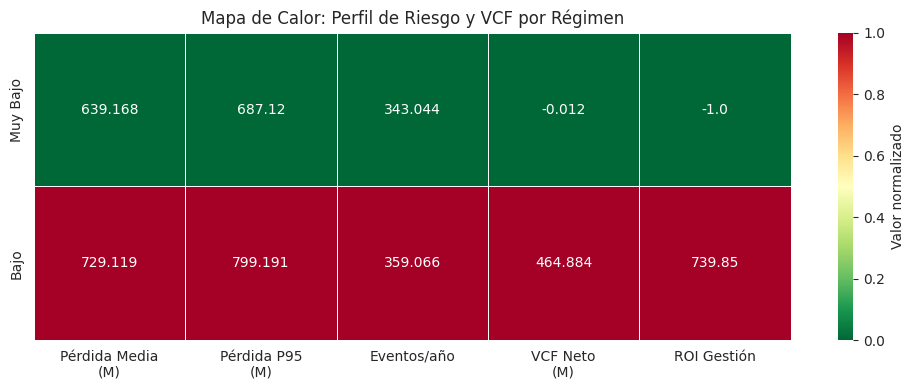

In [ ]:
# ── 6.2 Visualización integrada: mapa de calor cluster × métricas ────────────
cols_heatmap = ['Perdida_Media', 'Perdida_P95', 'Eventos_Medio', 'VCF_neto (M)', 'ROI_Gestion']
hm_data = perfil_sorted[cols_heatmap].astype(float)

# Normalizar para comparación visual
hm_norm = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min() + 1e-9)
hm_norm.index = perfil_sorted['Regimen'].values

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(hm_norm, annot=hm_data.values.round(3), fmt='', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Valor normalizado'})
ax.set_title('Mapa de Calor: Perfil de Riesgo y VCF por Régimen')
ax.set_xticklabels(['Pérdida Media\n(M)', 'Pérdida P95\n(M)', 'Eventos/año',
                    'VCF Neto\n(M)', 'ROI Gestión'], rotation=0)
plt.tight_layout()
plt.savefig('heatmap_regimenes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis de Silhouette detallado

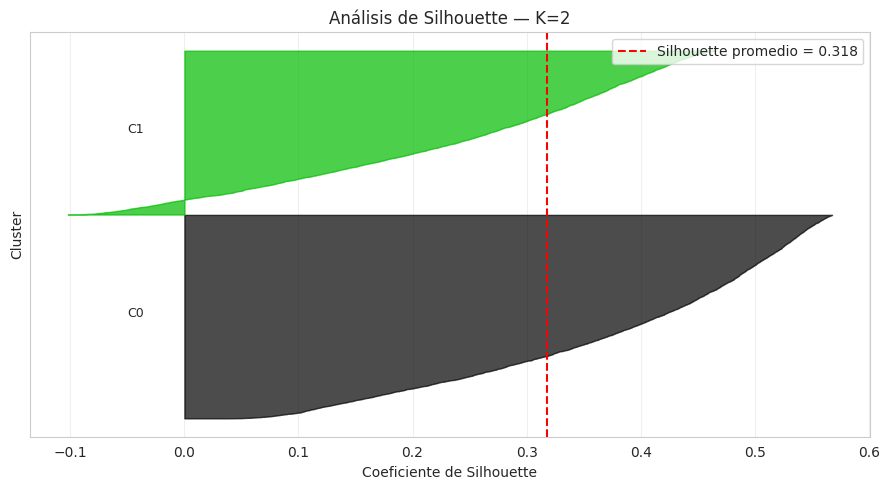

Silhouette promedio: 0.3181  (>0.5 = buena separación)


In [ ]:
# ── Gráfico de Silhouette por muestra ─────────────────────────────────────────
sample_vals  = silhouette_samples(X_scaled, df_km['Cluster'].values)
avg_sil      = silhouette_score(X_scaled, df_km['Cluster'].values)

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10

for k in range(K_FINAL):
    sil_k = np.sort(sample_vals[df_km['Cluster'] == k])
    size_k = len(sil_k)
    y_upper = y_lower + size_k
    color_k = cm.nipy_spectral(float(k) / K_FINAL)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k, alpha=0.7, color=color_k)
    ax.text(-0.05, y_lower + 0.5 * size_k, f'C{k}', fontsize=9)
    y_lower = y_upper + 10

ax.axvline(avg_sil, color='red', lw=1.5, linestyle='--', label=f'Silhouette promedio = {avg_sil:.3f}')
ax.set_xlabel('Coeficiente de Silhouette')
ax.set_ylabel('Cluster')
ax.set_title(f'Análisis de Silhouette — K={K_FINAL}')
ax.legend(loc='upper right')
ax.set_yticks([])

plt.tight_layout()
plt.savefig('silhouette_detalle.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Silhouette promedio: {avg_sil:.4f}  (>0.5 = buena separación)')

## 8. Resumen ejecutivo y conclusiones

In [ ]:
# ── Resumen ejecutivo ─────────────────────────────────────────────────────────
mejor_vcf = df_vcf.loc[df_vcf['VCF_neto (M)'].idxmax()]
mejor_roi = df_vcf.loc[df_vcf['ROI_Gestion'].idxmax()]

print('╔' + '═'*68 + '╗')
print('║  RESUMEN EJECUTIVO — GESTIÓN PROSPECTIVA DE RIESGOS TECNOLÓGICOS  ║')
print('╠' + '═'*68 + '╣')
print(f'║  Eventos históricos analizados     : {len(df):>6}                      ║')
print(f'║  Frecuencia media (λ Poisson)      : {lambda_hat:>6.1f} eventos/año          ║')
print(f'║  Parámetros Log-Normal: μ={mu_hat:.3f}, σ={sigma_hat:.3f}                  ║')
print(f'║  Pérdida Esperada anual (EL base)  : {EL_base:>8.4f} M USD/año       ║')
print(f'║  VaR al 95%                        : {VaR_95:>8.4f} M USD           ║')
print(f'║  VaR al 99%                        : {VaR_99:>8.4f} M USD           ║')
print(f'║  Clusters K-Means identificados    : {K_FINAL:>6}                      ║')
print(f'║  Silhouette promedio               : {avg_sil:>8.4f}                 ║')
print('╠' + '═'*68 + '╣')
print(f'║  Nivel gestión con mayor VCF neto  : {mejor_vcf["Nombre"]:>20}          ║')
print(f'║    VCF Neto                        : {mejor_vcf["VCF_neto (M)"]:>8.4f} M USD/año       ║')
print(f'║    Costo de gestión                : {mejor_vcf["Costo_Gestion (M)"]:>8.4f} M USD/año       ║')
print(f'║  Nivel gestión con mayor ROI       : {mejor_roi["Nombre"]:>20}          ║')
print(f'║    ROI Gestión                     : {mejor_roi["ROI_Gestion"]:>8.2f}x                ║')
print('╠' + '═'*68 + '╣')
print('║  INDICADOR GEI (Valor Capturado Financiero):                       ║')
print('║  El VCF representa el ahorro neto en pérdidas por cada nivel de    ║')
print('║  inversión en gestión prospectiva, análogo al costo de abatimiento ║')
print('║  de GEI: mayor VCF → mayor captura de valor ambiental-financiero.  ║')
print('╚' + '═'*68 + '╝')

╔════════════════════════════════════════════════════════════════════╗
║  RESUMEN EJECUTIVO — GESTIÓN PROSPECTIVA DE RIESGOS TECNOLÓGICOS  ║
╠════════════════════════════════════════════════════════════════════╣
║  Eventos históricos analizados     :    701                      ║
║  Frecuencia media (λ Poisson)      :  350.5 eventos/año          ║
║  Parámetros Log-Normal: μ=0.207, σ=0.955                  ║
║  Pérdida Esperada anual (EL base)  : 679.9875 M USD/año       ║
║  VaR al 95%                        : 776.7441 M USD           ║
║  VaR al 99%                        : 821.3170 M USD           ║
║  Clusters K-Means identificados    :      2                      ║
║  Silhouette promedio               :   0.3181                 ║
╠════════════════════════════════════════════════════════════════════╣
║  Nivel gestión con mayor VCF neto  :              Crítico          ║
║    VCF Neto                        : 464.8838 M USD/año       ║
║    Costo de gestión                :   0.6283

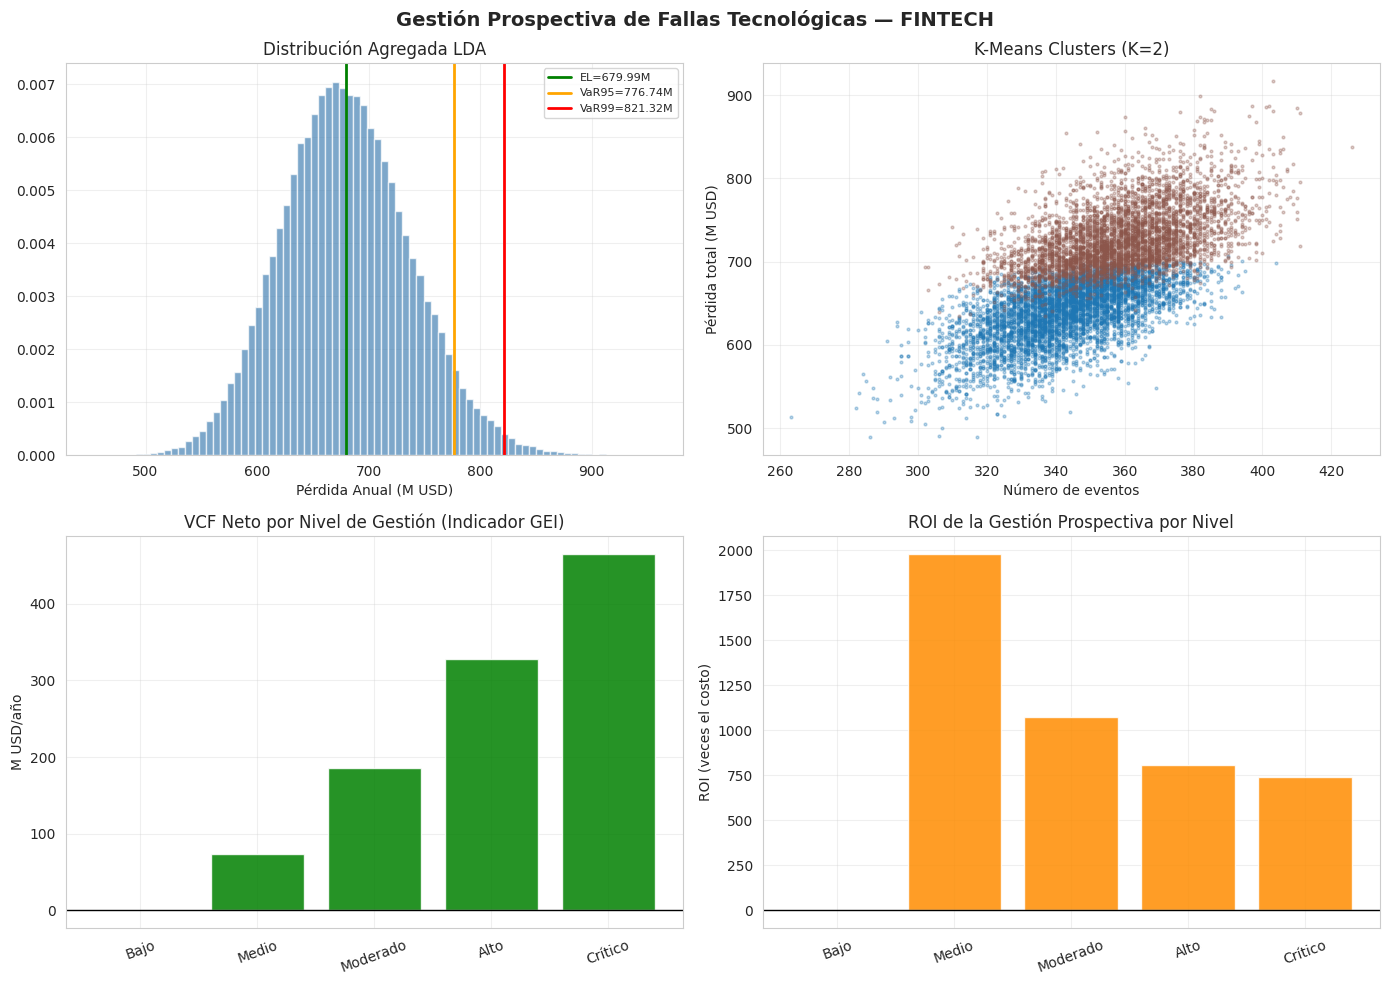


✅ Parcial II completado exitosamente.


In [ ]:
# ── Gráfico resumen final ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución agregada con VaRs
axes[0,0].hist(perdidas_agregadas, bins=80, density=True, color='steelblue', alpha=0.7)
axes[0,0].axvline(EL_base, color='green', lw=2, label=f'EL={EL_base:.2f}M')
axes[0,0].axvline(VaR_95, color='orange', lw=2, label=f'VaR95={VaR_95:.2f}M')
axes[0,0].axvline(VaR_99, color='red', lw=2, label=f'VaR99={VaR_99:.2f}M')
axes[0,0].set_title('Distribución Agregada LDA')
axes[0,0].set_xlabel('Pérdida Anual (M USD)')
axes[0,0].legend(fontsize=8)

# 2. Clusters (total vs n_eventos)
for k in range(K_FINAL):
    mask = df_km['Cluster'] == k
    axes[0,1].scatter(df_km.loc[mask,'n_eventos'], df_km.loc[mask,'total'],
                      s=4, alpha=0.3, color=cm.tab10(k/K_FINAL))
axes[0,1].set_title(f'K-Means Clusters (K={K_FINAL})')
axes[0,1].set_xlabel('Número de eventos')
axes[0,1].set_ylabel('Pérdida total (M USD)')

# 3. VCF por nivel
colores_vcf2 = ['green' if v >= 0 else 'red' for v in df_vcf['VCF_neto (M)']]
axes[1,0].bar(df_vcf['Nombre'], df_vcf['VCF_neto (M)'], color=colores_vcf2, alpha=0.85)
axes[1,0].axhline(0, color='black', lw=1)
axes[1,0].set_title('VCF Neto por Nivel de Gestión (Indicador GEI)')
axes[1,0].set_ylabel('M USD/año')
axes[1,0].tick_params(axis='x', rotation=20)

# 4. ROI por nivel
axes[1,1].bar(df_vcf['Nombre'], df_vcf['ROI_Gestion'], color='darkorange', alpha=0.85)
axes[1,1].axhline(0, color='black', lw=1)
axes[1,1].set_title('ROI de la Gestión Prospectiva por Nivel')
axes[1,1].set_ylabel('ROI (veces el costo)')
axes[1,1].tick_params(axis='x', rotation=20)

plt.suptitle('Gestión Prospectiva de Fallas Tecnológicas — FINTECH', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resumen_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Mapa de Gestión de Riesgos

Este mapa visualiza los distintos regímenes de riesgo identificados mediante K-Means, mostrando su pérdida media, el nivel de gestión asignado y el Valor Capturado Financiero (VCF) asociado. Esto permite una comprensión clara de la estrategia óptima de gestión para cada perfil de riesgo.

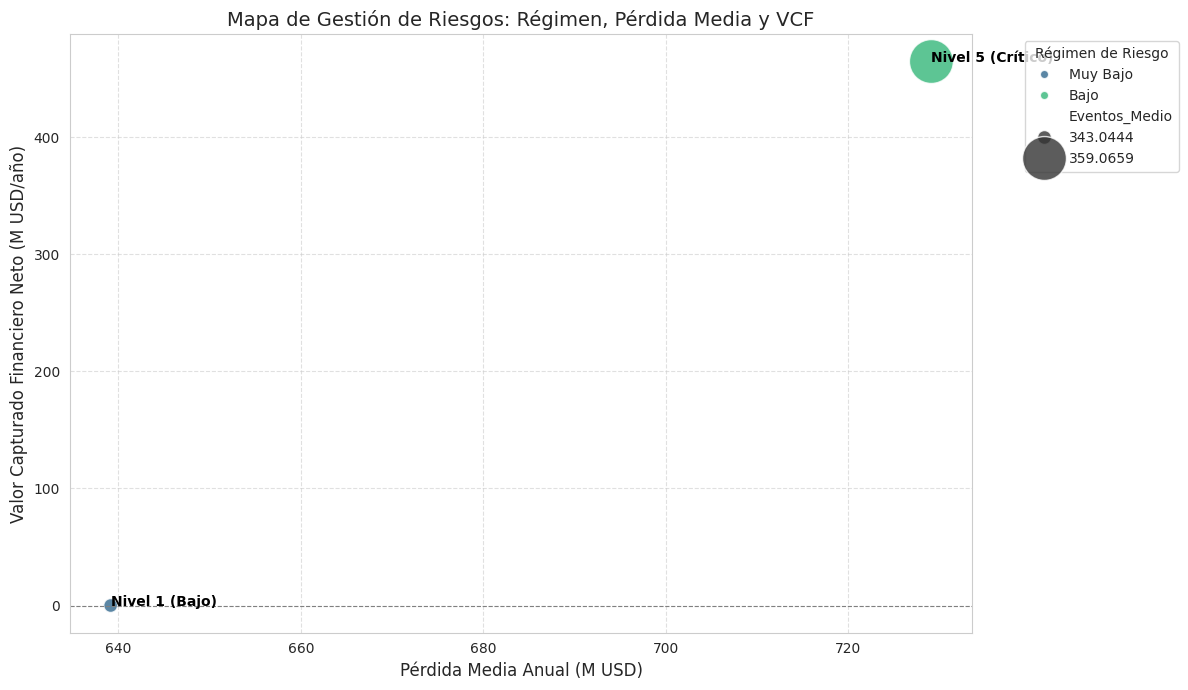

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure VCF_neto (M) is numeric
perfil_sorted['VCF_neto (M)'] = pd.to_numeric(perfil_sorted['VCF_neto (M)'])

fig, ax = plt.subplots(figsize=(13, 8)) # Slightly larger figure for more detail

# Create the scatter plot
scatter = sns.scatterplot(
    data=perfil_sorted,
    x='Perdida_Media',
    y='VCF_neto (M)',
    hue='Regimen',
    size='Eventos_Medio',
    sizes=(200, 1500), # Adjust size range for more distinct circles
    palette='viridis',
    alpha=0.8,
    edgecolor='w',
    linewidth=1.5, # Slightly thicker edge for points
    ax=ax
)

# Add horizontal line at VCF=0
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Add detailed annotations to each point
for idx, row in perfil_sorted.iterrows():
    text_label = (
        f"Regimen: {row['Regimen']} (Cluster {row['Cluster']})\n"
        f"Gestión: Nivel {row['Nivel_Gestion']} ({row['Nombre']})\n"
        f"Pérdida Media: {row['Perdida_Media']:.2f} M USD\n"
        f"Pérdida P95: {row['Perdida_P95']:.2f} M USD\n"
        f"VCF Neto: {row['VCF_neto (M)']:.2f} M USD/año\n"
        f"ROI Gestión: {row['ROI_Gestion']:.2f}x"
    )

    # Determine text position to avoid overlap or be more readable
    # For two points, a simple offset should work
    x_offset = 15
    y_offset = 15 if row['VCF_neto (M)'] >= 0 else -15 # Place above if VCF positive, below if negative

    ax.annotate(
        text_label,
        (row['Perdida_Media'], row['VCF_neto (M)']),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        ha='left',
        va='center', # Vertical alignment of text box
        fontsize=9,
        color='black',
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="steelblue", lw=0.8, alpha=0.9)
    )

ax.set_title('Mapa de Gestión de Riesgos Estratégicos: Régimen, Pérdida y VCF', fontsize=15, fontweight='bold')
ax.set_xlabel('Pérdida Media Anual (M USD)', fontsize=12)
ax.set_ylabel('Valor Capturado Financiero Neto (M USD/año)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

# Adjust legend placement to not overlap with annotations
handles_hue, labels_hue = scatter.legend_elements("hue", num_categories=len(perfil_sorted['Regimen'].unique()))
legend1 = ax.legend(handles_hue, labels_hue, title="Régimen", loc='upper left', bbox_to_anchor=(1.05, 1))
ax.add_artist(legend1) # Add the first legend manually

handles_size, labels_size = scatter.legend_elements("size", prop="sizes", num_segments=3) # Adjust num_segments as needed
legend2 = ax.legend(handles_size, labels_size, title="Eventos Medio", loc='lower left', bbox_to_anchor=(1.05, 0))

plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legends
plt.savefig('mapa_gestion_riesgos_mejorado.png', dpi=150, bbox_inches='tight')
plt.show()